In [10]:
## The goal of this notebook is to study the applicability of private (non-)membership proof delegation
## in a stateless blockchain application. The empirical data is taken from here: https://insights.glassnode.com/time-is-money-how-coin-age-shapes-bitcoins-spending-patterns/

In [76]:
import numpy as np
import matplotlib.pyplot as plt
import math
from matplotlib.colors import LogNorm

In [39]:
## Transaction per second that we want to simulate
## We roughly both want to capture Bitcoin (7 tps), Ethereum's throguhput with L2s (100 tps roughly) and VISA/Mastercard (10k tps)
tps = [2**i for i in range(0,17,2)]
## Offline-time interval length (this is the offline period length that we can support)
offline_time = [2**i for i in range(3,28,3)] ## in seconds

In [89]:
## Bitcoin's empirical coin age follows a power-law distribution
## See the data and measurements here: https://insights.glassnode.com/time-is-money-how-coin-age-shapes-bitcoins-spending-patterns/
## This power-law distribution can be approximated with the following line on a log-log scale
intercept = -1.4159
slope = -0.9550
## To ease calculations let's just compute with the average of this distribution
average_coin_age_days = 300 ## in days (this is a rough estimation given the empirical data above)
average_coin_age_seconds = 25920000 ## in seconds
miliSecondsInHour = 3600000
hoursInMonth = 731

In [65]:
tx3_large_cost_per_hour = 0.208  # in USD, from https://calculator.aws/#/createCalculator/ec2-enhancement on 2026-04-09

In [62]:
bilinear_running_times = [1.593770,3.538859,9.606699,	26.058632,	65.352250,	131.966387,	274.302579,	790.240733]
y = [math.log2(i) for i in bilinear_running_times]
x = [i+3 for i in range(len(y))]
print(x)
print(y)
## Linear regression results on the data above (R^2=0.9990)
intercept_runtimes = -2.4808
slope_runtimes = 1.0367

[3, 4, 5, 6, 7, 8, 9, 10]
[0.6724434462662564, 1.8232842811038672, 3.2640407853757254, 4.703689443619993, 6.0301650020322075, 7.044026699027231, 8.099624376281072, 9.626148401798412]


In [63]:
print(tps)

[1, 4, 16, 64, 256, 1024, 4096, 16384, 65536]


In [118]:
## Bilinear membership proof-delegation
noOfThreads = 8 ## number of threads at the AWS server machine
crs_length = 2**28 ## currently, this is the largest Powers-of-tau trusted setup that one could use in an application without relying on an entirely new trusted setup ceremony
bilinear_upd_cost = np.zeros((len(tps),len(offline_time)))
for i in range(0,len(tps)):
    for j in range(0,len(offline_time)):
        if tps[i]*offline_time[j]<crs_length: ##otherwise, it would not even be possible to do the membership proof update
            necessaryUpdatesPerCoin = average_coin_age_seconds*tps[i]
            updates_per_threads = (tps[i]*(slope_runtimes*(math.log2(necessaryUpdatesPerCoin))+intercept_runtimes))/noOfThreads
            upd_cost_per_hour = updates_per_threads/miliSecondsInHour ## the workload can be done in parallel
            bilinear_upd_cost[i,j]=(upd_cost_per_hour*tx3_large_cost_per_hour*hoursInMonth*12) ## let's assume the server is running for 1 year=12 months
bilinear_upd_cost

array([[1.46033196e-03, 1.46033196e-03, 1.46033196e-03, 1.46033196e-03,
        1.46033196e-03, 1.46033196e-03, 1.46033196e-03, 1.46033196e-03,
        1.46033196e-03],
       [6.36675505e-03, 6.36675505e-03, 6.36675505e-03, 6.36675505e-03,
        6.36675505e-03, 6.36675505e-03, 6.36675505e-03, 6.36675505e-03,
        0.00000000e+00],
       [2.75687290e-02, 2.75687290e-02, 2.75687290e-02, 2.75687290e-02,
        2.75687290e-02, 2.75687290e-02, 2.75687290e-02, 0.00000000e+00,
        0.00000000e+00],
       [1.18681751e-01, 1.18681751e-01, 1.18681751e-01, 1.18681751e-01,
        1.18681751e-01, 1.18681751e-01, 1.18681751e-01, 0.00000000e+00,
        0.00000000e+00],
       [5.08354346e-01, 5.08354346e-01, 5.08354346e-01, 5.08354346e-01,
        5.08354346e-01, 5.08354346e-01, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00],
       [2.16792675e+00, 2.16792675e+00, 2.16792675e+00, 2.16792675e+00,
        2.16792675e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.0

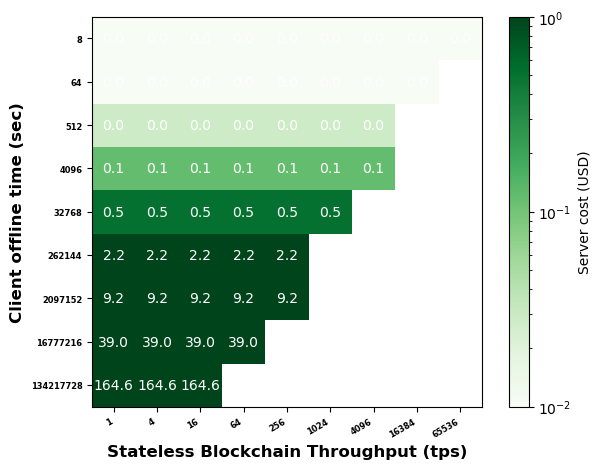

In [117]:
fig, ax = plt.subplots()

im = ax.imshow(bilinear_upd_cost, cmap='Greens', interpolation='nearest',norm=LogNorm(vmin=0.01, vmax=1))
plt.xlabel('Stateless Blockchain Throughput (tps)', fontweight='bold', color = 'black', fontsize='12', horizontalalignment='center')
plt.xticks(range(0,len(tps)), tps, color='black', rotation=30, fontweight='bold', fontsize='6', horizontalalignment='right')
plt.ylabel('Client offline time (sec)', fontweight='bold', color = 'black', fontsize='12', horizontalalignment='center')
plt.yticks(range(0,len(offline_time)), offline_time, color='black', fontweight='bold', fontsize='6', horizontalalignment='right')

# Loop over data dimensions and create text annotations.
for i in range(len(tps)):
    for j in range(len(offline_time)):
        text = ax.text(j, i, round(bilinear_upd_cost[i, j],1),
                       ha="center", va="center", color="w")

plt.colorbar(im,label="Server cost (USD)")
fig.tight_layout()
plt.show()

In [82]:
## RSA membership proof-delegation